In [1]:
import pandas as pd
import joblib
import numpy as np
from utils.helper_survival_graphs import *

c:\Users\aferr\miniconda3\envs\i3lung\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
complete_data = pd.read_csv('data/rwd.csv')
train_set = pd.read_csv('mlef_pipeline/results/OS/C23/RWD/train_set.csv')
test_set = pd.read_csv('mlef_pipeline/results/OS/C23/RWD/test_set.csv')
model = joblib.load('mlef_pipeline/results/OS/C23/RWD/model_COX.pkl')

In [3]:
test_set = pd.merge(
    test_set,
    complete_data[['Subject', 'LIPI']],
    on='Subject',
    how='left'
)

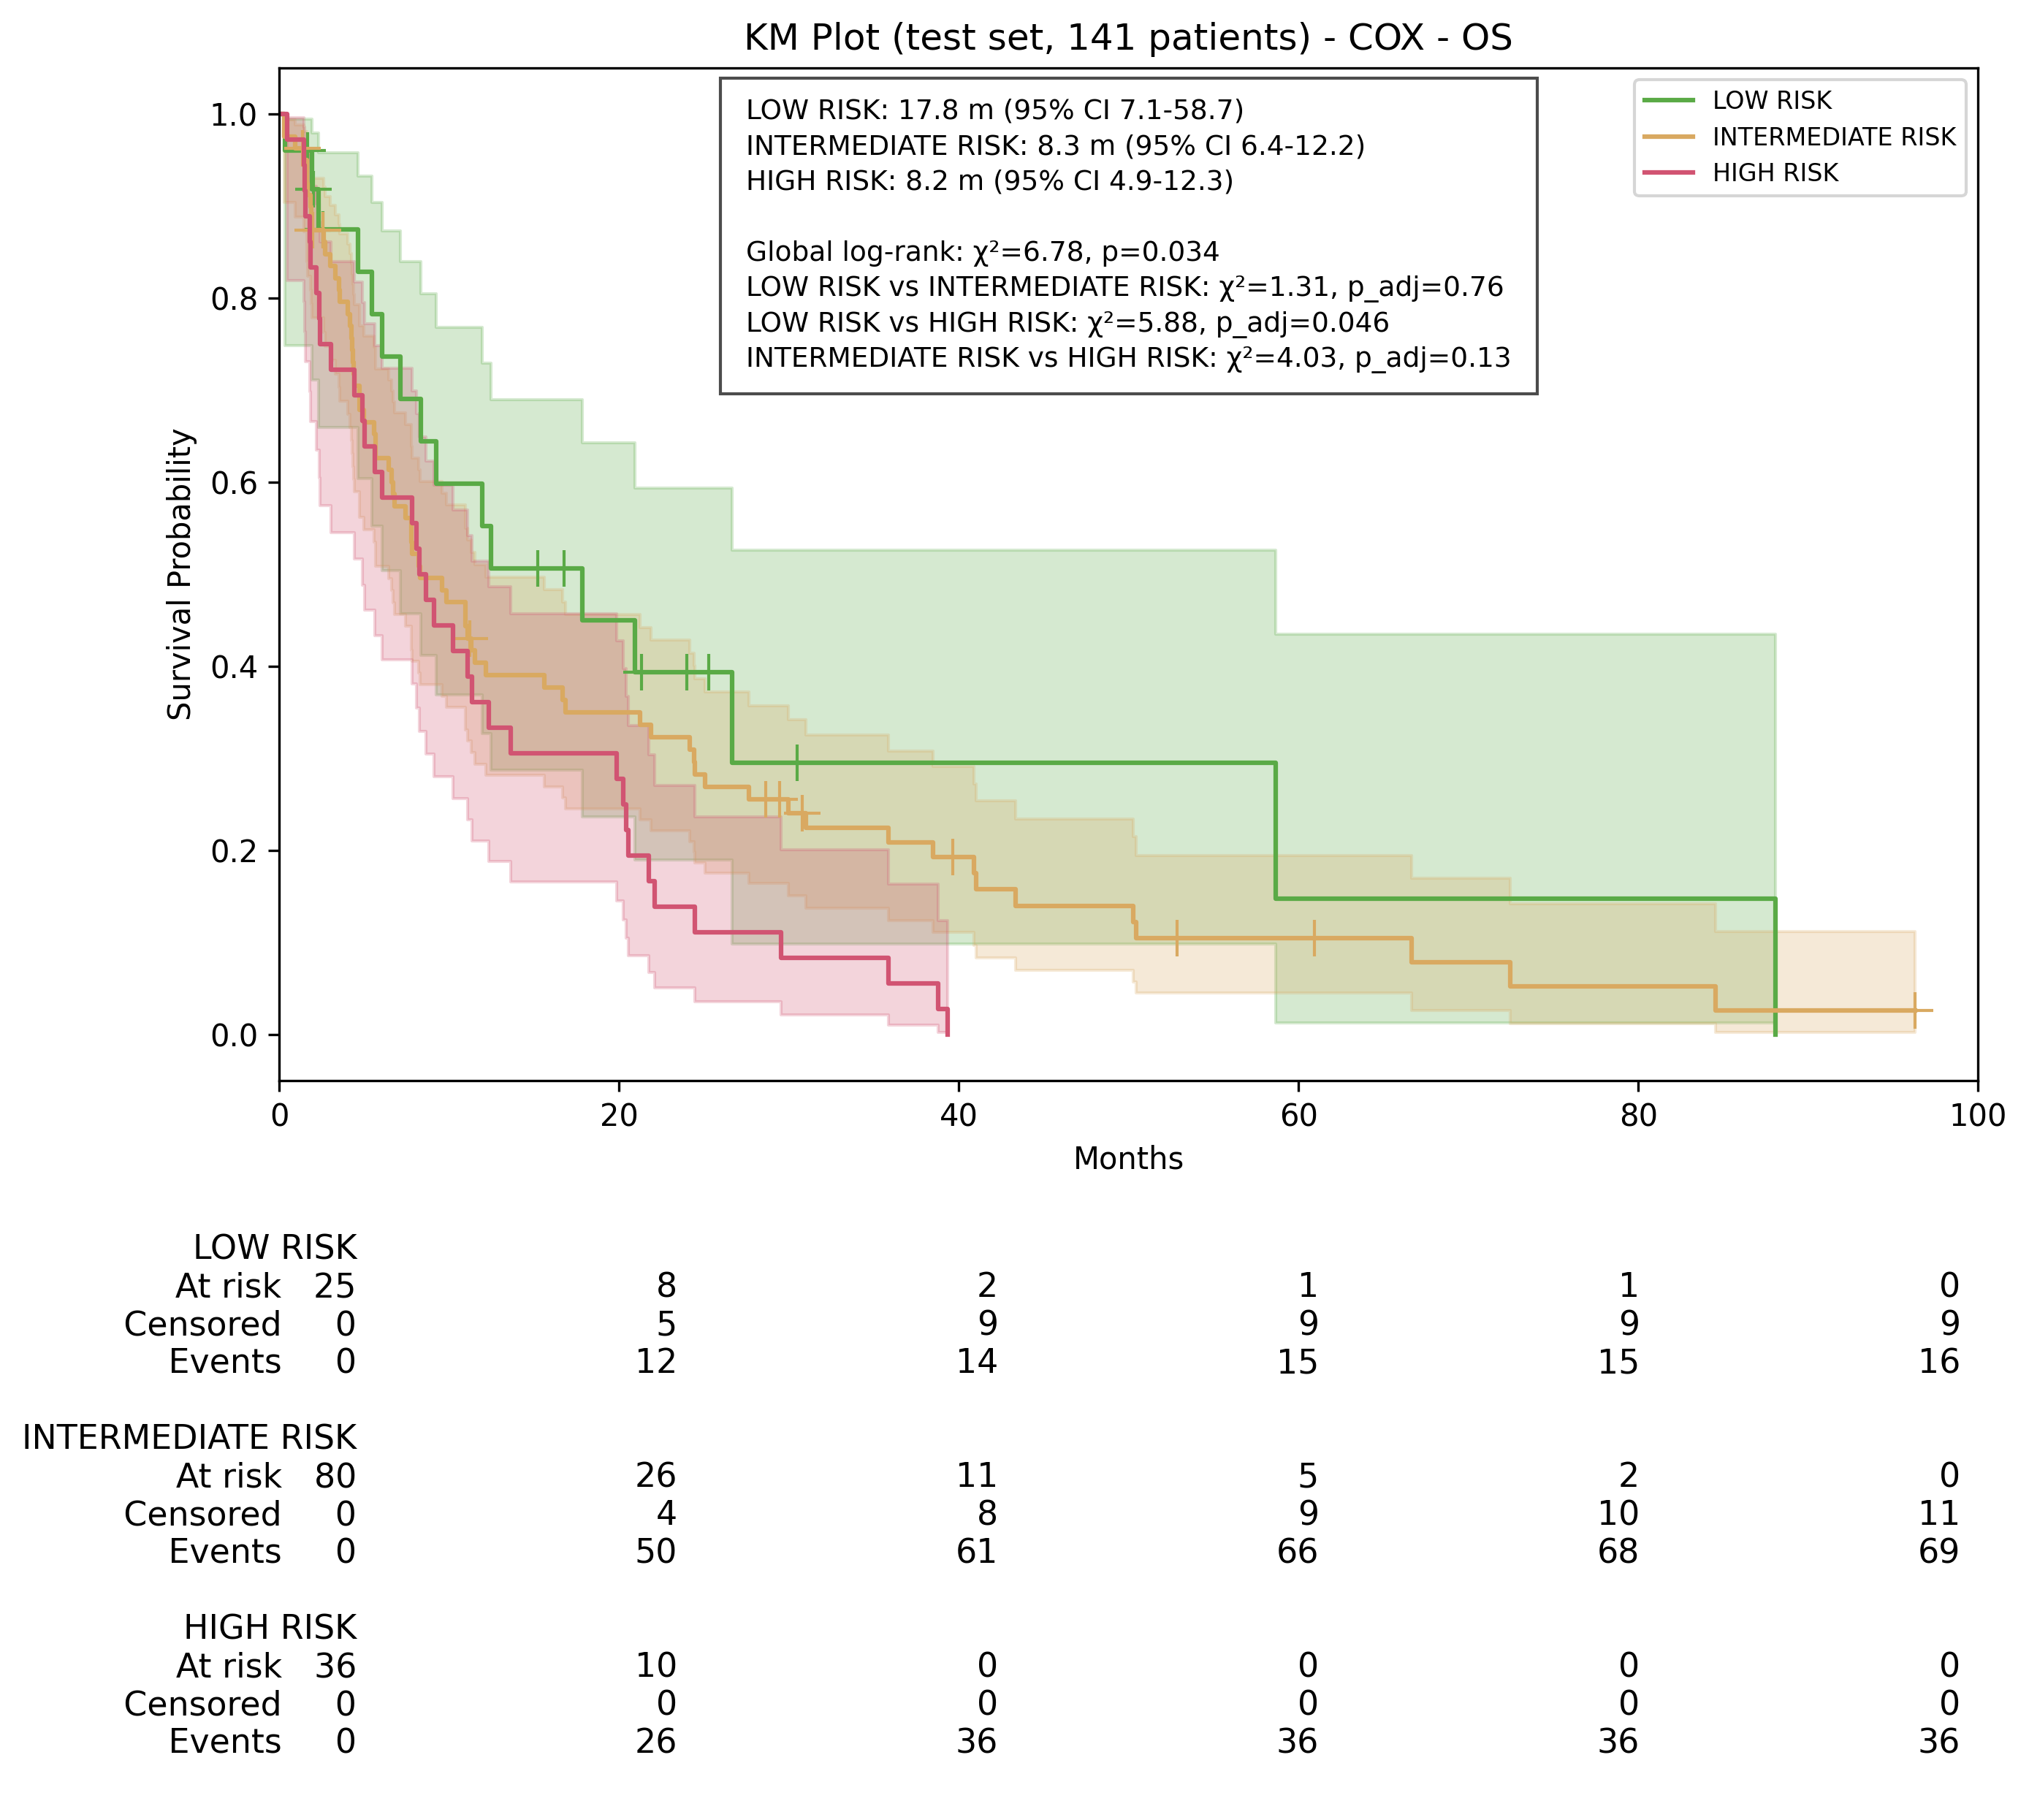

In [4]:
# Stratified by LIPI [Fig. e(i)]

good = test_set[test_set['LIPI'] == 0]
inter = test_set[test_set['LIPI'] == 1]
bad = test_set[test_set['LIPI'] == 2]

# Plot the combined Kaplan-Meier curve for OS
plot, df = plot_km_combined(
    datasets={
        'LOW RISK': good,
        'INTERMEDIATE RISK': inter,
        'HIGH RISK': bad,
    }, 
    stats=True
)

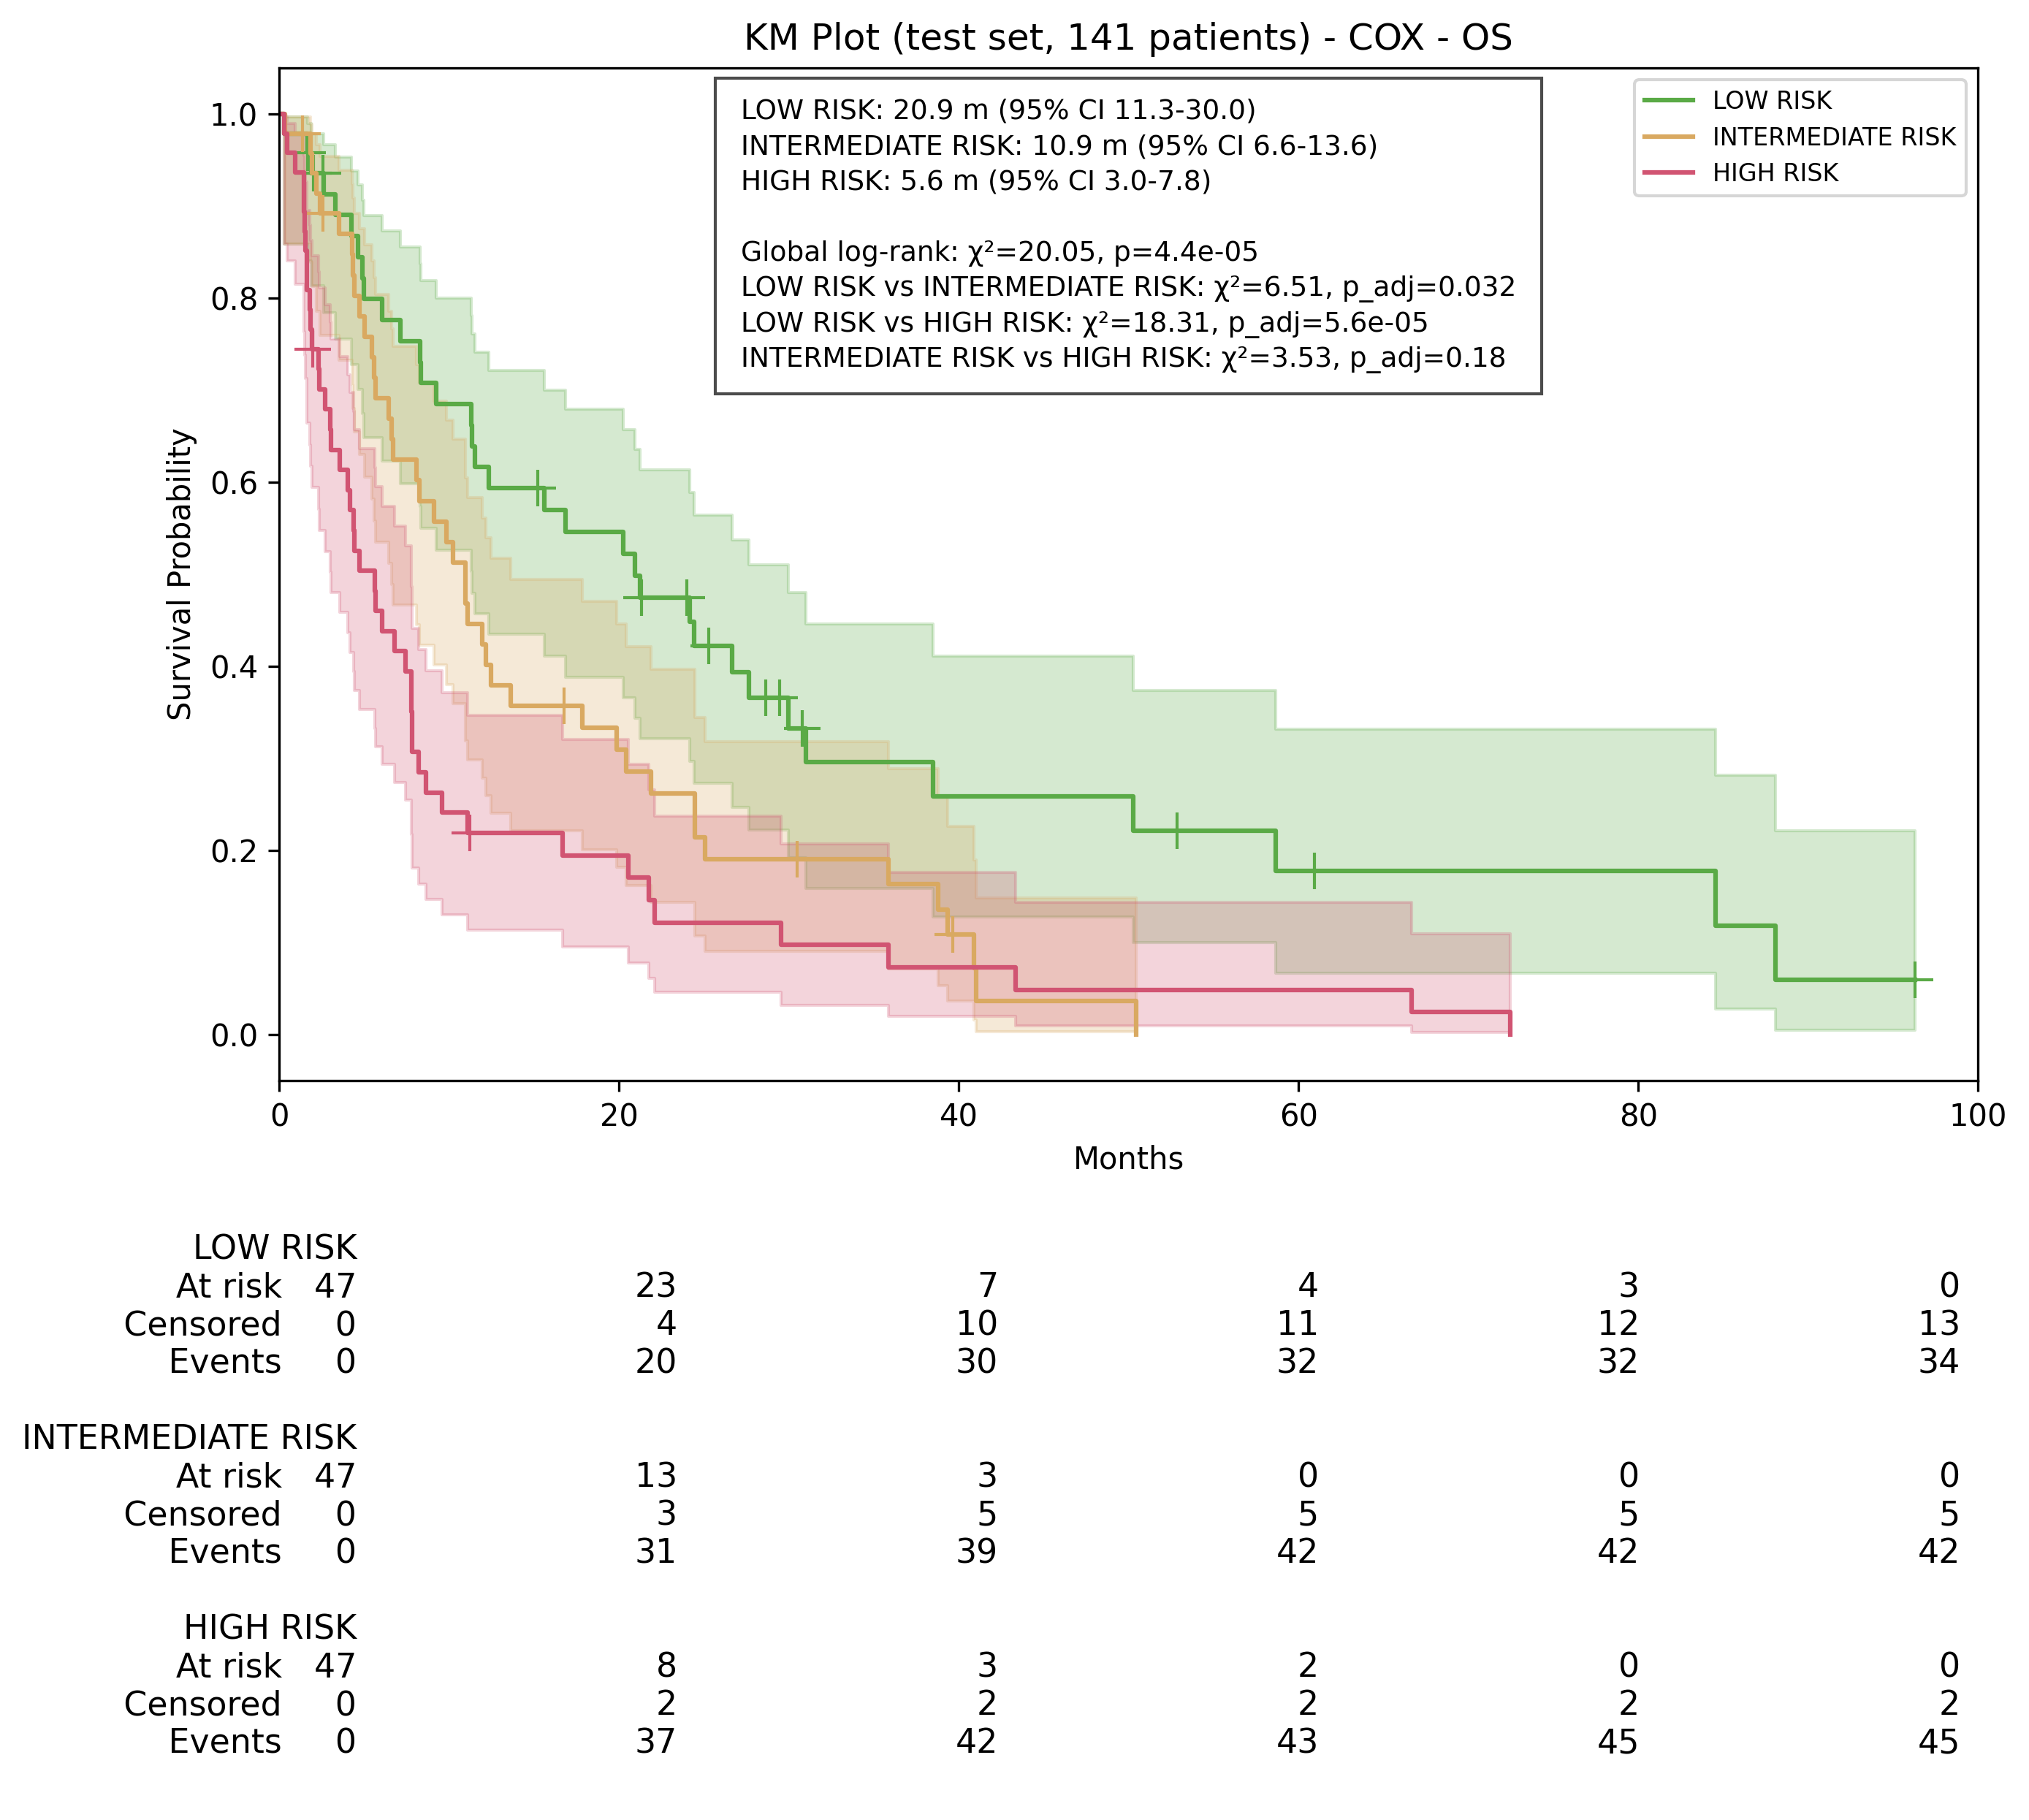

In [5]:
# Stratified by lipi [Fig. e(ii)]

lipi_df = test_set[test_set['LIPI'].notna()].reset_index(drop=True)
risk_scores = model.predict_partial_hazard(lipi_df).reset_index(drop=True)
tertiles = np.percentile(risk_scores, [33.33, 66.67])
lipi_df['risk_group'] = pd.cut(
    risk_scores,
    bins=[-np.inf, tertiles[0], tertiles[1], np.inf],
    labels=['Low risk', 'Intermediate risk', 'High risk'],
    include_lowest=True
)
low_risk = lipi_df[lipi_df['risk_group'] == 'Low risk']
intermediate_risk = lipi_df[lipi_df['risk_group'] == 'Intermediate risk']
high_risk = lipi_df[lipi_df['risk_group'] == 'High risk']

# Plot the combined Kaplan-Meier curve for OS
plot, df = plot_km_combined(
    datasets={
        'LOW RISK': low_risk, 
        'INTERMEDIATE RISK': intermediate_risk,
        'HIGH RISK': high_risk
    }, 
    stats=True
)

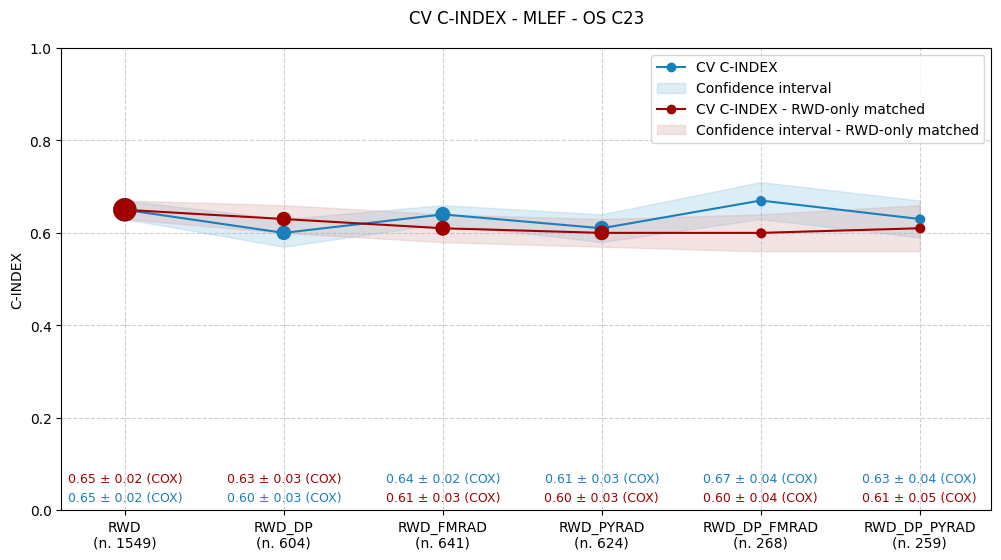

In [6]:
plot_cindex_results(
    architecture="MLEF",
    outcome="OS",
    analyses=["C23"],
    modality_order=[
        "RWD",
        "RWD_DP",
        "RWD_FMRAD",
        "RWD_PYRAD",
        "RWD_DP_FMRAD",
        "RWD_DP_PYRAD"
    ],
    exclude_modalities=("DP", "FMRAD", "PYRAD"),
    title_prefix=None,
    min_bubble=30,
    max_bubble=250,
    show=True,
    save_dir=None
)

PermutationExplainer explainer: 274it [00:19,  9.84it/s]                         


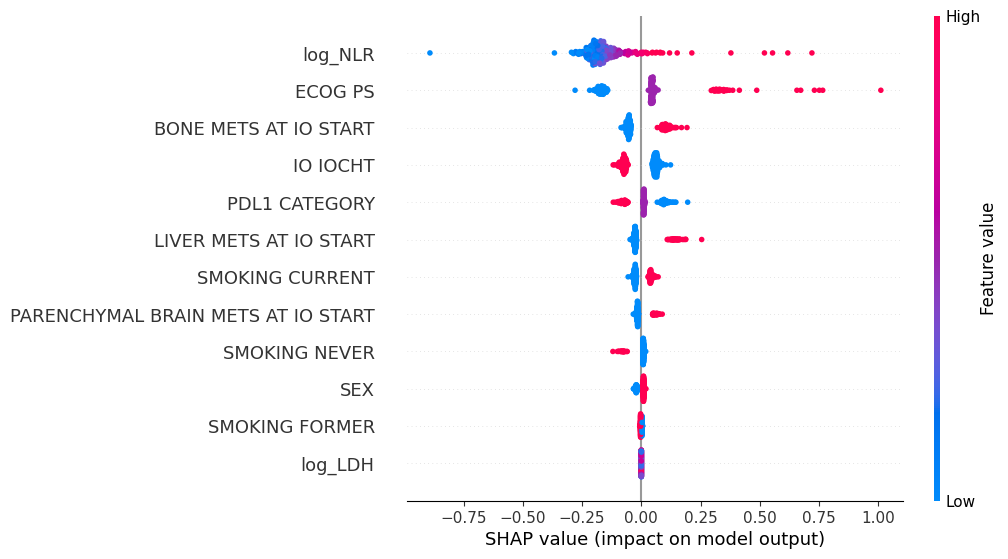

In [7]:
features = train_set.drop(columns=['Subject', 'TIME', 'EVENT', 'FOLD']).columns

plt = shap_beeswarm(
    model=model,
    X_train=train_set[features],
    X_test=test_set[features],
    mapping={}
)